In [62]:
import random
import matplotlib.pyplot as plt
import numpy as np
from treasure_env import MultiTreasureHunterMDP,  LEFT, RIGHT, UP, DOWN, ACTIONS
SAVE_AGENTS = True

# Środowisko

In [64]:
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3
ACTIONS = [(-1, 0), (0, 1), (1, 0), (0, -1)]

class MultiTreasureHunterMDP:
    def __init__(self, map_lines):
        self.original_map = [list(row) for row in map_lines]
        self.height = len(self.original_map)
        self.width = len(self.original_map[0])
        self.treasures = set()
        self.bases = {}
        self.agent_pos = {}
        self.agent_holding = {'1': False, '2': False}
        self.agent_score = {'1': 0, '2': 0}
        self.winning_score = len([tile for row in self.original_map for tile in row if tile == 'T']) // 2 + 1

    def reset(self):
        self.map = [row[:] for row in self.original_map]
        self.treasures = set()
        self.bases = {}
        self.agent_holding = {'1': False, '2': False}
        self.agent_score = {'1': 0, '2': 0}

        for y in range(self.height):
            for x in range(self.width):
                tile = self.map[y][x]
                if tile == 'T':
                    self.treasures.add((x, y))
                elif tile == 'A':
                    self.bases['1'] = (x, y)
                    self.map[y][x] = '.'
                elif tile == 'B':
                    self.bases['2'] = (x, y)
                    self.map[y][x] = '.'

        self.agent_pos['1'] = self.bases['1']
        self.agent_pos['2'] = self.bases['2']

        return self._get_state()

    def _get_state(self):
        return (
            self.agent_pos['1'],
            self.agent_pos['2'],
            frozenset(self.treasures),
            self.agent_holding['1'],
            self.agent_holding['2']
        )
    
    def get_agent_state(self, state, agent_id):
        pos1, pos2, treasures, hold1, hold2 = state
        
        if agent_id == '1':
            return (pos1, pos2, frozenset(treasures), hold1, hold2)
        else:
            return (pos2, pos1, frozenset(treasures), hold2, hold1)


    def get_possible_actions(self, state=None, agent_id='1'):
        if state is None:
            return [LEFT, DOWN, RIGHT, UP]
        
        my_pos, _, _, _, _ = state
        x, y = my_pos

        # pos1, pos2, _, _, _ = state
        # agent_pos = pos1 if agent_id == '1' else pos2
        # x, y = agent_pos
        
        possible_actions = []
        for action in [LEFT, DOWN, RIGHT, UP]:
            _x, _y = ACTIONS[action]
            new_x, new_y = x + _x, y + _y
            
            if 0 <= new_x < self.width and 0 <= new_y < self.height:
                if self.map[new_y][new_x] != '#':
                    possible_actions.append(action)
        
        return possible_actions

    def _move(self, agent_id, action):
        x, y = self.agent_pos[agent_id]
        _x, _y = ACTIONS[action]
        new_x, new_y = x + _x, y + _y

        if not (0 <= new_x < self.width and 0 <= new_y < self.height):
            return x, y
        if self.map[new_y][new_x] == '#':
            return x, y
        
        other_pos = self.agent_pos['2'] if agent_id == '1' else self.agent_pos['1']
        if (new_x, new_y) == other_pos:
            return x, y

        return new_x, new_y

    def step(self, action1, action2):
        rewards = {'1': 0.0, '2': 0.0}
        info = {}

        prev_pos1 = self.agent_pos['1']
        prev_pos2 = self.agent_pos['2']

        self.agent_pos['1'] = self._move('1', action1)
        self.agent_pos['2'] = self._move('2', action2)
        rewards['1'] -= 1
        rewards['2'] -= 1

        if self.agent_pos['1'] == self.agent_pos['2']:
            collision_pos = self.agent_pos['1']
            
            if self.agent_holding['1']:
                self.treasures.add(prev_pos1)
                self.agent_holding['1'] = False
                info['1_drop_collision'] = True
            
            if self.agent_holding['2']:
                self.treasures.add(prev_pos2)
                self.agent_holding['2'] = False
                info['2_drop_collision'] = True
            
            self.agent_pos['1'] = self.bases['1']
            self.agent_pos['2'] = self.bases['2']
            
            rewards['1'] -= 5
            rewards['2'] -= 5
            info['collision'] = True

        for agent_id, pos, prev_pos in [('1', self.agent_pos['1'], prev_pos1), ('2', self.agent_pos['2'], prev_pos2)]:
            x, y = pos

            if self.map[y][x] == 'H':
                if self.agent_holding[agent_id]:
                    self.treasures.add(prev_pos)
                    self.agent_holding[agent_id] = False
                    info[f'{agent_id}_drop_trap'] = True
                
                self.agent_pos[agent_id] = self.bases[agent_id]
                rewards[agent_id] = -30
                info[f'{agent_id}_trap'] = True
                continue

            if pos in self.treasures and not self.agent_holding[agent_id]:
                self.treasures.remove(pos)
                self.agent_holding[agent_id] = True
                rewards[agent_id] += 4
                info[f'{agent_id}_pick'] = True

            if pos == self.bases[agent_id] and self.agent_holding[agent_id]:
                self.agent_holding[agent_id] = False
                self.agent_score[agent_id] += 1  
                rewards[agent_id] += 8 
                info[f'{agent_id}_deposit'] = True

        done = self._is_done()
        return self._get_state(), rewards, done, info

    def _is_done(self):
        # check_trap1 = self.map[self.agent_pos['1'][1]][self.agent_pos['1'][0]] == 'H'
        # check_trap2 = self.map[self.agent_pos['2'][1]][self.agent_pos['2'][0]] == 'H'

        if self.agent_score['1'] == self.winning_score or self.agent_score['2'] == self.winning_score:
            return True

        check_treasure = len(self.treasures) == 0

        check_both_home = (
            self.agent_pos['1'] == self.bases['1'] and
            self.agent_pos['2'] == self.bases['2'] and
            not self.agent_holding['1'] and not self.agent_holding['2']
        )
        # return (check_trap1 and check_trap2) or (check_treasure and check_both_home)
        return check_treasure and check_both_home

    def render(self):
        pass
        # grid = [row[:] for row in self.map]
        # for x, y in self.treasures:
        #     grid[y][x] = 'T'
        # p1, p2 = self.agent_pos['1'], self.agent_pos['2']
        # grid[p1[1]][p1[0]] = if self.agent_holding['1'] else '1'
        # grid[p2[1]][p2[0]] = if self.agent_holding['2'] else '2'

        # print("\n" + "="*40)
        # for row in grid:
        #     print(''.join(row))
        # print(f"Skarby: {len(self.treasures)} | Punkty: 1:{self.agent_score['1']}  2:{self.agent_score['2']}")
        # print(f"Trzyma: 1:{self.agent_holding['1']}  2:{self.agent_holding['2']}")
        # print("="*40)

In [ ]:
def play_and_train_multi(env, agent1, agent2, episodes=5000, use_agent_perspective=True, 
                         epsilon_start=0.9, epsilon_end=0.05):
    rewards_history_agent1 = []
    rewards_history_agent2 = []
    scores_history_agent1 = []
    scores_history_agent2 = []
    
    epsilon_decay = (epsilon_end / epsilon_start) ** (1 / episodes)
    
    print(f"Epsilon decay: {epsilon_decay:.6f} (od {epsilon_start} do {epsilon_end} w {episodes} epizodach)")
    
    epsilon1 = epsilon_start
    epsilon2 = epsilon_start

    for ep in range(episodes):
        agent1.epsilon = max(epsilon_end, epsilon1)
        agent2.epsilon = max(epsilon_end, epsilon2)
        
        state = env.reset()
        total_r1 = total_r2 = 0
        agent1.reset()
        agent2.reset()
        
        if use_agent_perspective:
            state1 = env.get_agent_state(state, '1')
            state2 = env.get_agent_state(state, '2')
        else:
            state1 = state2 = state
        
        action1 = agent1.get_action(state1)
        action2 = agent2.get_action(state2)

        while True:
            env_next_state, rewards, done, _ = env.step(action1, action2)
            r1, r2 = rewards['1'], rewards['2']
            total_r1 += r1
            total_r2 += r2

            if use_agent_perspective:
                next_state1 = env.get_agent_state(env_next_state, '1')
                next_state2 = env.get_agent_state(env_next_state, '2')
            else:
                next_state1 = next_state2 = env_next_state

            next_action1 = agent1.update(state1, action1, r1, next_state1)
            next_action2 = agent2.update(state2, action2, r2, next_state2)

            action1 = next_action1 if next_action1 is not None else agent1.get_action(next_state1)
            action2 = next_action2 if next_action2 is not None else agent2.get_action(next_state2)
            
            state1 = next_state1
            state2 = next_state2

            if done:
                break
        
        epsilon1 *= epsilon_decay
        epsilon2 *= epsilon_decay

        score1 = env.agent_score['1']
        score2 = env.agent_score['2']
        
        rewards_history_agent1.append(total_r1)
        rewards_history_agent2.append(total_r2)
        scores_history_agent1.append(score1)
        scores_history_agent2.append(score2)

        if (ep + 1) % 100 == 0:
            print(f"Epizod {ep+1:4d} | Agent1: R={total_r1:6.1f} P={score1} Eps={agent1.epsilon:.3f} | Agent2: R={total_r2:6.1f} P={score2} Eps={agent2.epsilon:.3f}")

    return (rewards_history_agent1, rewards_history_agent2, 
            scores_history_agent1, scores_history_agent2)

In [ ]:
import time

def test_policy(env, agent1, agent2, episodes=3, delay=0.3, max_steps=100, use_agent_perspective=True):
    agent1.turn_off_learning()
    agent2.turn_off_learning()
    
    action_names = {
        0: '<< LEWO',
        1: '\/ DÓŁ',
        2: '>> PRAWO',
        3: '/\ GÓRA'
    }

    for ep in range(episodes):
        state = env.reset()
        print(f"\n{'='*50}")
        print(f"GRA TESTOWA {ep+1}")
        print(f"{'='*50}")
        step = 0

        while step < max_steps:
            if use_agent_perspective:
                state1 = env.get_agent_state(state, '1')
                state2 = env.get_agent_state(state, '2')
            else:
                state1 = state2 = state

            a1 = agent1.get_action(state1)
            a2 = agent2.get_action(state2)
            state, rewards, done, info = env.step(a1, a2)
            step += 1
            
            events = []
            if '1_pick' in info:
                events.append("T: A1")
            if '2_pick' in info:
                events.append("T: A2")
            if '1_deposit' in info:
                events.append("[H]: A1")
            if '2_deposit' in info:
                events.append("[H]: A2")
            
            event_str = " " + " ".join(events) if events else ""
            print(f"Krok {step:2d}: A1={action_names[a1]}, A2={action_names[a2]} | R1={rewards['1']:+.0f} R2={rewards['2']:+.0f}{event_str}")
            
            time.sleep(delay)
            
            if done:
                print(f"\n{'='*50}")
                print(f"KONIEC GRY {ep+1} (w {step} krokach)")
                score1 = env.agent_score['1']
                score2 = env.agent_score['2']
                print(f"Wynik końcowy:")
                print(f"  Agent 1: {score1} punktów")
                print(f"  Agent 2: {score2} punktów")
                
                if score1 > score2:
                    print(f"\nWYGRYWA Agent 1 z przewagą {score1 - score2} punktów!")
                elif score2 > score1:
                    print(f"\nWYGRYWA Agent 2 z przewagą {score2 - score1} punktów!")
                else:
                    print(f"\nREMIS! Obaj agenci zdobyli {score1} punktów!")
                print(f"{'='*50}")
                break
        
        if step >= max_steps:
            print(f"\nPRZERWANO - osiągnięto limit {max_steps} kroków!")
            print(f"Punkty: A1={env.agent_score['1']}, A2={env.agent_score['2']}")

<>:9: SyntaxWarning: invalid escape sequence '\/'
<>:11: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\/'
<>:11: SyntaxWarning: invalid escape sequence '\ '
C:\Users\jasin\AppData\Local\Temp\ipykernel_1540\3837222095.py:9: SyntaxWarning: invalid escape sequence '\/'
  1: '\/ DÓŁ',
C:\Users\jasin\AppData\Local\Temp\ipykernel_1540\3837222095.py:11: SyntaxWarning: invalid escape sequence '\ '
  3: '/\ GÓRA'


In [69]:
MAP1 = [
    "A....T....",
    "..#..#..#.",
    "T.......H.",
    "..#..T..#.",
    "....H....B"
]

MAP2 = [
    "A........T",
    "..#..#..#.",
    ".H..T...H.",
    ".#..#..#..",
    "T........B"
]

MAP3 = [
    "A....H...T",
    ".#.#....#.",
    ".H.#T..#H.",
    "..#...H.#.",
    "T...H....B"
]

In [70]:
import importlib
import agents
importlib.reload(agents)
from agents import QLearningAgent, SARSAAgent, ExpectedSARSAAgent


Trening agentów (Q-Learning vs SARSA):
Epsilon decay: 0.999711 (od 0.9 do 0.05 w 10000 epizodach)
Epizod  100 | Agent1: R=-545.0 P=2 Eps=0.875 | Agent2: R=-1013.0 P=1 Eps=0.875
Epizod  200 | Agent1: R=-2307.0 P=1 Eps=0.850 | Agent2: R=-2771.0 P=2 Eps=0.850
Epizod  300 | Agent1: R=  -4.0 P=2 Eps=0.825 | Agent2: R= -45.0 P=1 Eps=0.825
Epizod  400 | Agent1: R=-476.0 P=1 Eps=0.802 | Agent2: R=-995.0 P=2 Eps=0.802
Epizod  500 | Agent1: R= -22.0 P=2 Eps=0.779 | Agent2: R=-129.0 P=0 Eps=0.779
Epizod  600 | Agent1: R= -29.0 P=2 Eps=0.757 | Agent2: R= -99.0 P=1 Eps=0.757
Epizod  700 | Agent1: R=-105.0 P=2 Eps=0.735 | Agent2: R=-254.0 P=1 Eps=0.735
Epizod  800 | Agent1: R=-299.0 P=1 Eps=0.714 | Agent2: R=-424.0 P=2 Eps=0.714
Epizod  900 | Agent1: R= -85.0 P=2 Eps=0.694 | Agent2: R=-213.0 P=1 Eps=0.694
Epizod 1000 | Agent1: R= -50.0 P=2 Eps=0.674 | Agent2: R=-211.0 P=0 Eps=0.674
Epizod 1100 | Agent1: R=   4.0 P=2 Eps=0.655 | Agent2: R= -49.0 P=0 Eps=0.655
Epizod 1200 | Agent1: R= -36.0 P=2 Eps=0

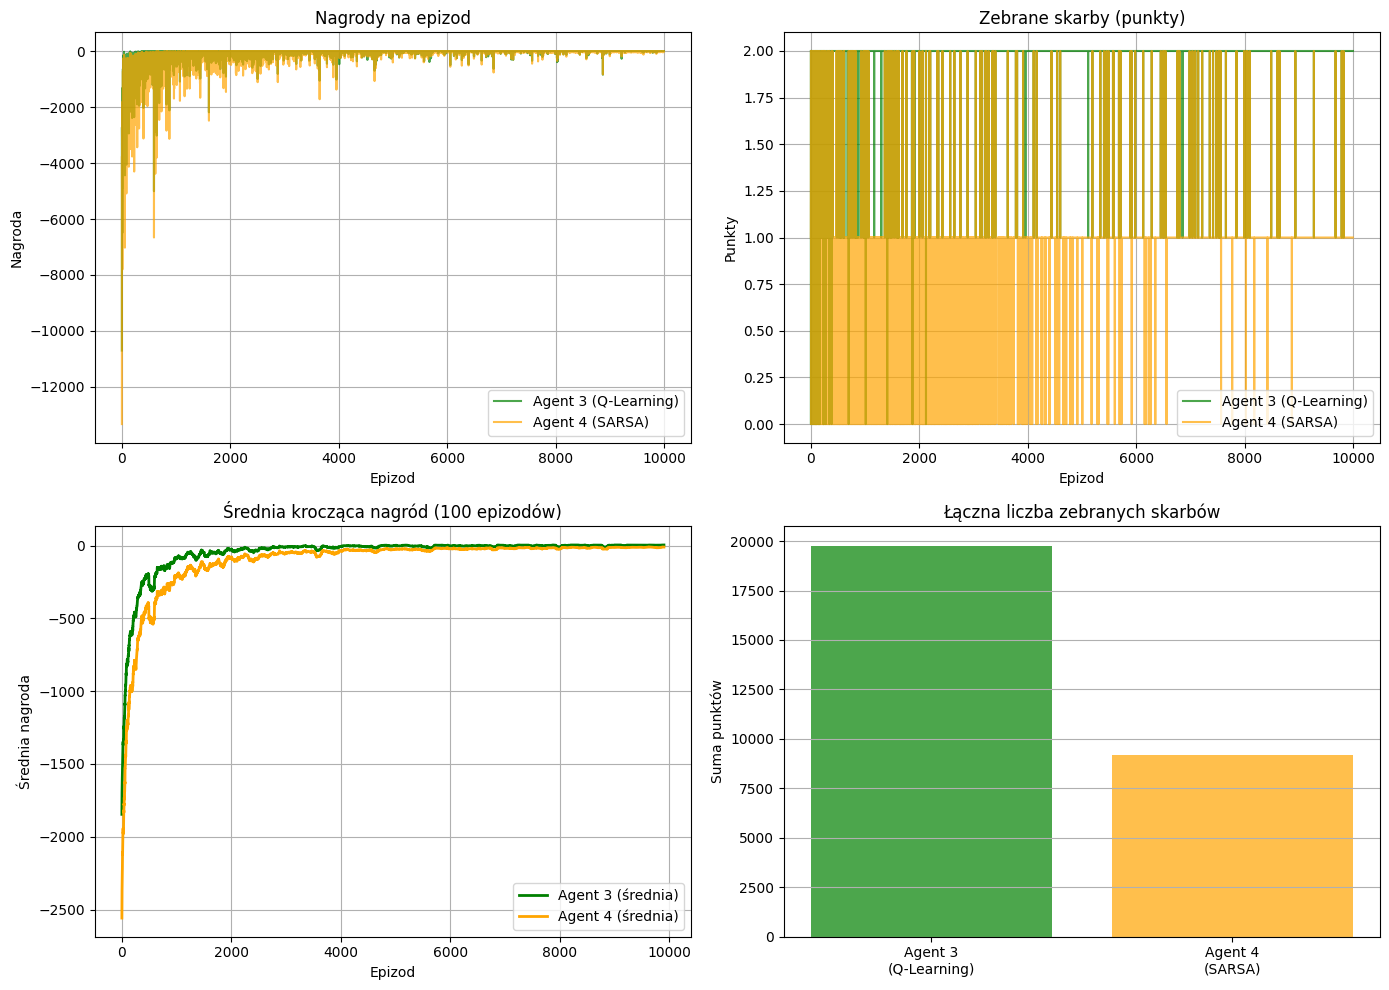

Agent 3 (Q-Learning): Łącznie punktów: 19757, Średnia nagroda: -57.2
Agent 4 (SARSA):      Łącznie punktów: 9184, Średnia nagroda: -116.9

=== TESTOWANIE WYTRENOWANEJ POLITYKI (Q-Learning vs SARSA) ===

GRA TESTOWA 1
Krok  1: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  2: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  3: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  4: A1=\/ DÓŁ, A2=/\ GÓRA | R1=+3 R2=+3 T: A1 T: A2
Krok  5: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  6: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  7: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  8: A1=/\ GÓRA, A2=\/ DÓŁ | R1=+7 R2=+7 [H]: A1 [H]: A2
Krok  9: A1=>> PRAWO, A2=/\ GÓRA | R1=-1 R2=-1
Krok 10: A1=>> PRAWO, A2=/\ GÓRA | R1=-1 R2=-1
Krok 11: A1=>> PRAWO, A2=\/ DÓŁ | R1=-1 R2=-1
Krok 12: A1=>> PRAWO, A2=\/ DÓŁ | R1=-1 R2=-1
Krok 13: A1=\/ DÓŁ, A2=<< LEWO | R1=-1 R2=-1
Krok 14: A1=\/ DÓŁ, A2=<< LEWO | R1=+3 R2=-1 T: A1
Krok 15: A1=/\ GÓRA, A2=<< LEWO | R1=-1 R2=-1
Krok 16: A1=/\ GÓRA, A2=>> PRAWO | R1=-1 R2=-1
Krok 17: A1=<< LEWO,

In [ ]:
env2 = MultiTreasureHunterMDP(MAP3)
state2 = env2.reset()

agentSARSA = SARSAAgent(
    alpha=0.1, epsilon=0.9, discount=0.9,
    get_legal_actions=lambda s: env2.get_possible_actions(s, agent_id='1')
)

agentQLearning = QLearningAgent(
    alpha=0.1, epsilon=0.9, discount=0.9,
    get_legal_actions=lambda s: env2.get_possible_actions(s, agent_id='2')
)

print("\nTrening agentów (Q-Learning vs SARSA):")
rewards3, rewards4, scores3, scores4 = play_and_train_multi(env2, agentSARSA, agentQLearning, episodes=10000)

print(f"\nAgent (Q-Learning) zna {len(agentSARSA._qvalues)} stanów")
print(f"Agent (SARSA) zna {len(agentQLearning._qvalues)} stanów")

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(rewards3, label='Agent 3 (Q-Learning)', alpha=0.7, color='green')
plt.plot(rewards4, label='Agent 4 (SARSA)', alpha=0.7, color='orange')
plt.title("Nagrody na epizod")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(scores3, label='Agent 3 (Q-Learning)', color='green', alpha=0.7)
plt.plot(scores4, label='Agent 4 (SARSA)', color='orange', alpha=0.7)
plt.title("Zebrane skarby (punkty)")
plt.xlabel("Epizod")
plt.ylabel("Punkty")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
window = 100
if len(rewards3) >= window:
    avg_r3 = np.convolve(rewards3, np.ones(window)/window, mode='valid')
    avg_r4 = np.convolve(rewards4, np.ones(window)/window, mode='valid')
    plt.plot(avg_r3, label='Agent 3 (średnia)', linewidth=2, color='green')
    plt.plot(avg_r4, label='Agent 4 (średnia)', linewidth=2, color='orange')
    plt.title(f"Średnia krocząca nagród ({window} epizodów)")
    plt.xlabel("Epizod")
    plt.ylabel("Średnia nagroda")
    plt.legend()
    plt.grid(True)

plt.subplot(2, 2, 4)
total_scores3 = sum(scores3)
total_scores4 = sum(scores4)
plt.bar(['Agent 3\n(Q-Learning)', 'Agent 4\n(SARSA)'], 
        [total_scores3, total_scores4], 
        color=['green', 'orange'], alpha=0.7)
plt.title("Łączna liczba zebranych skarbów")
plt.ylabel("Suma punktów")
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"Agent 3 (Q-Learning): Łącznie punktów: {total_scores3}, Średnia nagroda: {np.mean(rewards3):.1f}")
print(f"Agent 4 (SARSA):      Łącznie punktów: {total_scores4}, Średnia nagroda: {np.mean(rewards4):.1f}")

test_policy(env2, agentSARSA, agentQLearning, episodes=1, delay=0.3)

In [ ]:
if SAVE_AGENTS:
    try:
        import dill
    except ImportError:
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "dill"])
        import dill

    import os

    agents_dict = {
        'agent1': agentSARSA,
        'agent2': agentQLearning,
        'description': 'SARSA vs Q-Learning'
    }

    with open('agents_SARSA_vs_QLearning.pkl', 'wb') as f:
        dill.dump(agents_dict, f)
    print("[OK] Agenci zapisani jako: agents_SARSA_vs_QLearning.pkl")

    # Pokaz statystyki
    print("\n=== Statystyki zapisanych agentow ===")
    print(f"Agent 1 (SARSA):      {len(agentSARSA._qvalues)} znanych stanow")
    print(f"Agent 2 (Q-Learning): {len(agentQLearning._qvalues)} znanych stanow")

### QLearning vs ExpectedSARSA:


Trening agentów (Q-Learning vs ExpectedSARSA):
Epsilon decay: 0.999711 (od 0.9 do 0.05 w 10000 epizodach)
Epizod  100 | Agent1: R=-1669.0 P=0 Eps=0.875 | Agent2: R=-1914.0 P=2 Eps=0.875
Epizod  200 | Agent1: R=-7192.0 P=2 Eps=0.850 | Agent2: R=-7538.0 P=1 Eps=0.850
Epizod  300 | Agent1: R=-1588.0 P=1 Eps=0.825 | Agent2: R=-1630.0 P=2 Eps=0.825
Epizod  400 | Agent1: R=-3579.0 P=2 Eps=0.802 | Agent2: R=-3740.0 P=1 Eps=0.802
Epizod  500 | Agent1: R=-1173.0 P=2 Eps=0.779 | Agent2: R=-1060.0 P=0 Eps=0.779
Epizod  600 | Agent1: R=-2401.0 P=2 Eps=0.757 | Agent2: R=-2433.0 P=0 Eps=0.757
Epizod  700 | Agent1: R=-2625.0 P=0 Eps=0.735 | Agent2: R=-3070.0 P=2 Eps=0.735
Epizod  800 | Agent1: R=-1193.0 P=2 Eps=0.714 | Agent2: R=-1362.0 P=1 Eps=0.714
Epizod  900 | Agent1: R=-2012.0 P=2 Eps=0.694 | Agent2: R=-1854.0 P=0 Eps=0.694
Epizod 1000 | Agent1: R=-539.0 P=1 Eps=0.674 | Agent2: R=-472.0 P=1 Eps=0.674
Epizod 1100 | Agent1: R= -96.0 P=2 Eps=0.655 | Agent2: R=-178.0 P=0 Eps=0.655
Epizod 1200 | Age

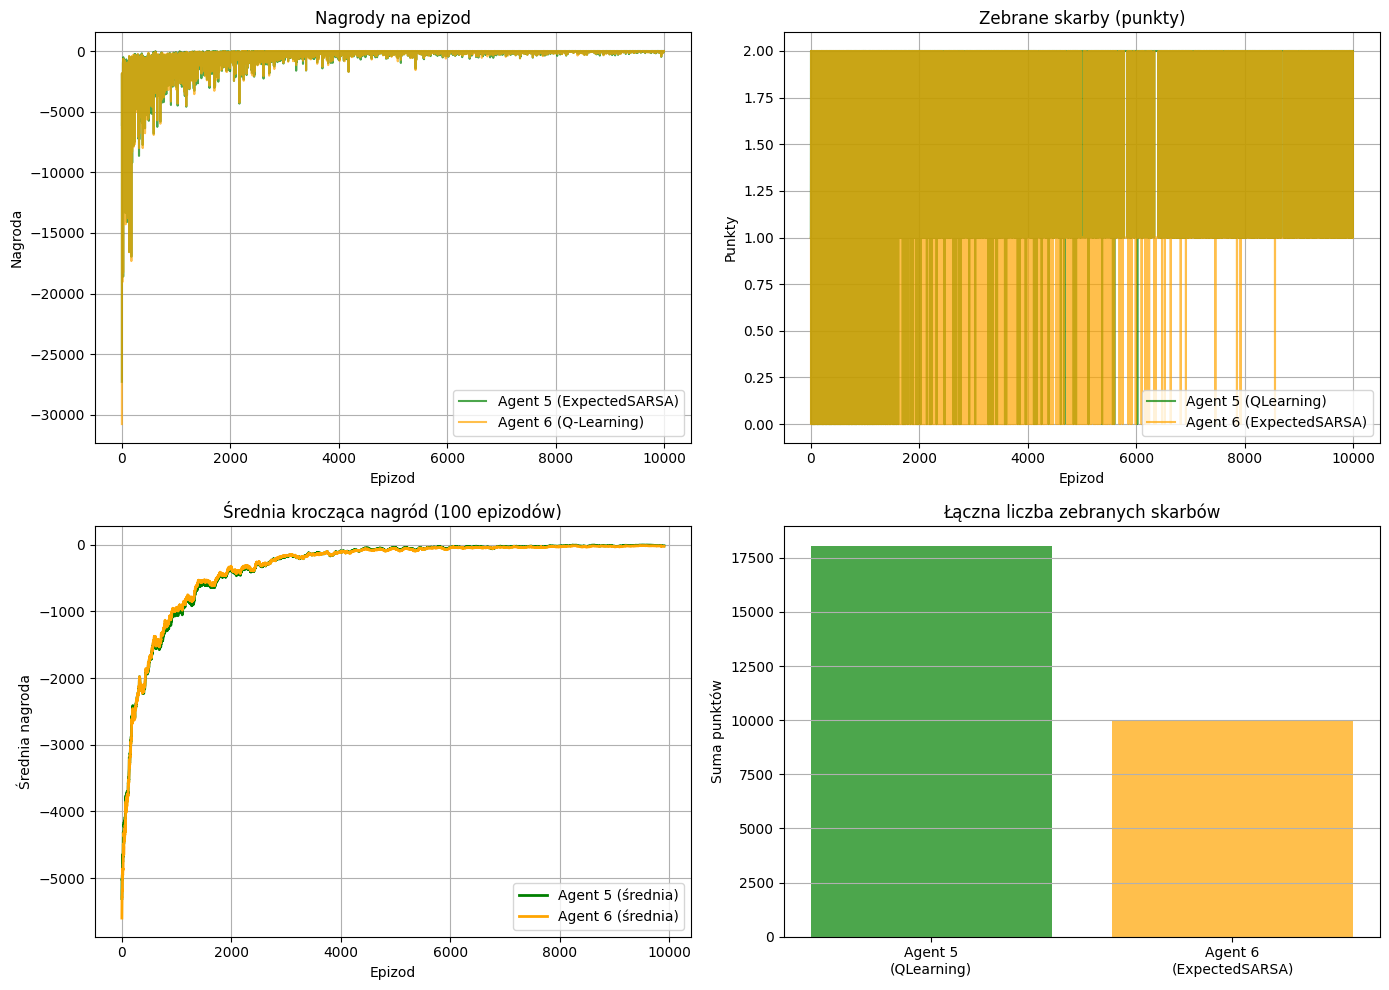

Agent 5 (QLearning): Łącznie punktów: 18050, Średnia nagroda: -370.7
Agent 6 (ExpectedSarsa):      Łącznie punktów: 9979, Średnia nagroda: -371.0

=== TESTOWANIE WYTRENOWANEJ POLITYKI (Q-Learning vs ExpectedSARSA) ===

GRA TESTOWA 1
Krok  1: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  2: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  3: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  4: A1=\/ DÓŁ, A2=/\ GÓRA | R1=+3 R2=+3 T: A1 T: A2
Krok  5: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  6: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  7: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  8: A1=/\ GÓRA, A2=\/ DÓŁ | R1=+7 R2=+7 [H]: A1 [H]: A2
Krok  9: A1=>> PRAWO, A2=/\ GÓRA | R1=-1 R2=-1
Krok 10: A1=>> PRAWO, A2=\/ DÓŁ | R1=-1 R2=-1
Krok 11: A1=>> PRAWO, A2=/\ GÓRA | R1=-1 R2=-1
Krok 12: A1=>> PRAWO, A2=\/ DÓŁ | R1=-1 R2=-1
Krok 13: A1=\/ DÓŁ, A2=<< LEWO | R1=-1 R2=-1
Krok 14: A1=\/ DÓŁ, A2=>> PRAWO | R1=+3 R2=-1 T: A1
Krok 15: A1=/\ GÓRA, A2=/\ GÓRA | R1=-1 R2=-1
Krok 16: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok 

In [ ]:
import matplotlib.pyplot as plt
env3 = MultiTreasureHunterMDP(MAP3)
state3 = env3.reset()

agentQLearningA = QLearningAgent(
    alpha=0.1, epsilon=0.9, discount=0.9,
    get_legal_actions=lambda s: env3.get_possible_actions(s, agent_id='1')
)

agentExpectedSARSA = ExpectedSARSAAgent(
    alpha=0.1, epsilon=0.9, discount=0.9,
    get_legal_actions=lambda s: env3.get_possible_actions(s, agent_id='2')
)

print("\nTrening agentów (Q-Learning vs ExpectedSARSA):")
rewards5, rewards6, scores5, scores6 = play_and_train_multi(env3, agentQLearningA, agentExpectedSARSA, episodes=10000)

print(f"\nAgent 5 (Q-Learning) zna {len(agentQLearning._qvalues)} stanów")
print(f"Agent 6 (ExpectedSARSA) zna {len(agentExpectedSARSA._qvalues)} stanów")

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(rewards5, label='Agent 5 (ExpectedSARSA)', alpha=0.7, color='green')
plt.plot(rewards6, label='Agent 6 (Q-Learning)', alpha=0.7, color='orange')
plt.title("Nagrody na epizod")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(scores5, label='Agent 5 (QLearning)', color='green', alpha=0.7)
plt.plot(scores6, label='Agent 6 (ExpectedSARSA)', color='orange', alpha=0.7)
plt.title("Zebrane skarby (punkty)")
plt.xlabel("Epizod")
plt.ylabel("Punkty")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
window = 100
if len(rewards5) >= window:
    avg_r5 = np.convolve(rewards5, np.ones(window)/window, mode='valid')
    avg_r6 = np.convolve(rewards6, np.ones(window)/window, mode='valid')
    plt.plot(avg_r5, label='Agent 5 (średnia)', linewidth=2, color='green')
    plt.plot(avg_r6, label='Agent 6 (średnia)', linewidth=2, color='orange')
    plt.title(f"Średnia krocząca nagród ({window} epizodów)")
    plt.xlabel("Epizod")
    plt.ylabel("Średnia nagroda")
    plt.legend()
    plt.grid(True)

plt.subplot(2, 2, 4)
total_scores5 = sum(scores5)
total_scores6 = sum(scores6)
plt.bar(['Agent 5\n(QLearning)', 'Agent 6\n(ExpectedSARSA)'], 
        [total_scores5, total_scores6], 
        color=['green', 'orange'], alpha=0.7)
plt.title("Łączna liczba zebranych skarbów")
plt.ylabel("Suma punktów")
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"Agent 5 (QLearning): Łącznie punktów: {total_scores5}, Średnia nagroda: {np.mean(rewards5):.1f}")
print(f"Agent 6 (ExpectedSarsa):      Łącznie punktów: {total_scores6}, Średnia nagroda: {np.mean(rewards6):.1f}")

test_policy(env3, agentQLearningA, agentExpectedSARSA, episodes=1, delay=0.3)

In [ ]:
if SAVE_AGENTS:
    try:
        import dill
    except ImportError:
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "dill"])
        import dill

    import os

    # Zapisz obu agentów do jednego pliku jako słownik
    agents_dict = {
        'agent1': agentQLearningA,
        'agent2': agentExpectedSARSA,
        'description': 'Q-Learning vs ExpectedSARSA'
    }

    with open('agents_QLearning_vs_ExpectedSARSA.pkl', 'wb') as f:
        dill.dump(agents_dict, f)
    print("[OK] Agenci zapisani jako: agents_QLearning_vs_ExpectedSARSA.pkl")

    # Pokaz statystyki
    print("\n=== Statystyki zapisanych agentow ===")
    print(f"Agent 1 (Q-Learning):    {len(agentQLearningA._qvalues)} znanych stanow")
    print(f"Agent 2 (ExpectedSARSA): {len(agentExpectedSARSA._qvalues)} znanych stanow")

### SARSA vs SARSA:


Trening agentów SARSA:
Epsilon decay: 0.999518 (od 0.9 do 0.05 w 6000 epizodach)
Epizod  100 | Agent1: R=-2458.0 P=1 Eps=0.858 | Agent2: R=-2837.0 P=1 Eps=0.858
Epizod  200 | Agent1: R= -66.0 P=1 Eps=0.818 | Agent2: R= -25.0 P=2 Eps=0.818
Epizod  300 | Agent1: R=-977.0 P=1 Eps=0.779 | Agent2: R=-1137.0 P=1 Eps=0.779
Epizod  400 | Agent1: R= -20.0 P=1 Eps=0.743 | Agent2: R=  -8.0 P=2 Eps=0.743
Epizod  500 | Agent1: R=-341.0 P=0 Eps=0.708 | Agent2: R=-213.0 P=2 Eps=0.708
Epizod  600 | Agent1: R=-306.0 P=1 Eps=0.674 | Agent2: R=-265.0 P=2 Eps=0.674
Epizod  700 | Agent1: R= -10.0 P=2 Eps=0.643 | Agent2: R= -22.0 P=1 Eps=0.643
Epizod  800 | Agent1: R=-152.0 P=2 Eps=0.612 | Agent2: R=-222.0 P=1 Eps=0.612
Epizod  900 | Agent1: R=   4.0 P=2 Eps=0.584 | Agent2: R=  -8.0 P=1 Eps=0.584
Epizod 1000 | Agent1: R=   4.0 P=2 Eps=0.556 | Agent2: R=  -8.0 P=1 Eps=0.556
Epizod 1100 | Agent1: R=   0.0 P=2 Eps=0.530 | Agent2: R= -12.0 P=1 Eps=0.530
Epizod 1200 | Agent1: R= -87.0 P=2 Eps=0.505 | Agent2: R=

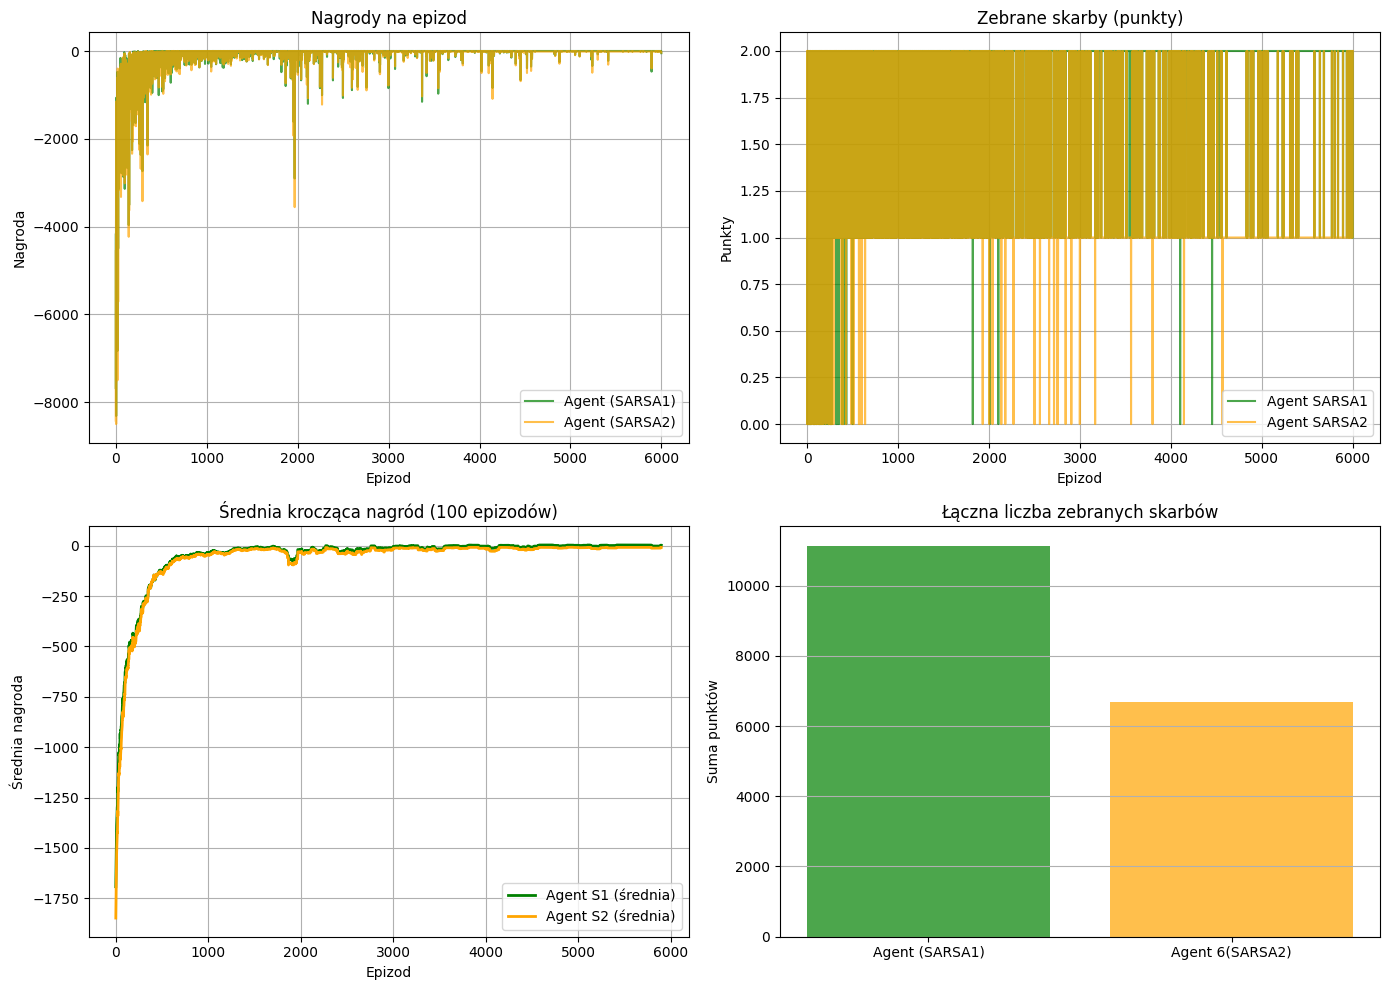

Agent 5 (SARSA1): Łącznie punktów: 11129, Średnia nagroda: -67.1
Agent 6 (SARSA2):      Łącznie punktów: 6679, Średnia nagroda: -80.7

=== TESTOWANIE WYTRENOWANEJ POLITYKI (Q-Learning vs ExpectedSARSA) ===

GRA TESTOWA 1
Krok  1: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  2: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  3: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok  4: A1=\/ DÓŁ, A2=/\ GÓRA | R1=+3 R2=+3 T: A1 T: A2
Krok  5: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  6: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  7: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok  8: A1=/\ GÓRA, A2=\/ DÓŁ | R1=+7 R2=+7 [H]: A1 [H]: A2
Krok  9: A1=>> PRAWO, A2=<< LEWO | R1=-1 R2=-1
Krok 10: A1=>> PRAWO, A2=<< LEWO | R1=-1 R2=-1
Krok 11: A1=>> PRAWO, A2=<< LEWO | R1=-1 R2=-1
Krok 12: A1=>> PRAWO, A2=<< LEWO | R1=-1 R2=-1
Krok 13: A1=\/ DÓŁ, A2=/\ GÓRA | R1=-1 R2=-1
Krok 14: A1=\/ DÓŁ, A2=<< LEWO | R1=+3 R2=-1 T: A1
Krok 15: A1=/\ GÓRA, A2=<< LEWO | R1=-1 R2=-1
Krok 16: A1=/\ GÓRA, A2=\/ DÓŁ | R1=-1 R2=-1
Krok 17: A1=<< L

In [ ]:
import matplotlib.pyplot as plt
env = MultiTreasureHunterMDP(MAP3)
state = env.reset()

agent_SARSA1 = SARSAAgent(
    alpha=0.1, epsilon=0.9, discount=0.9,
    get_legal_actions=lambda s: env3.get_possible_actions(s, agent_id='1')
)

agent_SARSA2 = SARSAAgent(
    alpha=0.1, epsilon=0.9, discount=0.9,
    get_legal_actions=lambda s: env3.get_possible_actions(s, agent_id='2')
)

print("\nTrening agentów SARSA:")
rewards5, rewards6, scores5, scores6 = play_and_train_multi(env, agent_SARSA1, agent_SARSA2, episodes=6000)

# print(f"\nAgent 5 (Q-Learning) zna {len(agent5._qvalues)} stanów")
# print(f"Agent 6 (ExpectedSARSA) zna {len(agent6._qvalues)} stanów")

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(rewards5, label='Agent (SARSA1)', alpha=0.7, color='green')
plt.plot(rewards6, label='Agent (SARSA2)', alpha=0.7, color='orange')
plt.title("Nagrody na epizod")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(scores5, label='Agent SARSA1', color='green', alpha=0.7)
plt.plot(scores6, label='Agent SARSA2', color='orange', alpha=0.7)
plt.title("Zebrane skarby (punkty)")
plt.xlabel("Epizod")
plt.ylabel("Punkty")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
window = 100
if len(rewards5) >= window:
    avg_r5 = np.convolve(rewards5, np.ones(window)/window, mode='valid')
    avg_r6 = np.convolve(rewards6, np.ones(window)/window, mode='valid')
    plt.plot(avg_r5, label='Agent S1 (średnia)', linewidth=2, color='green')
    plt.plot(avg_r6, label='Agent S2 (średnia)', linewidth=2, color='orange')
    plt.title(f"Średnia krocząca nagród ({window} epizodów)")
    plt.xlabel("Epizod")
    plt.ylabel("Średnia nagroda")
    plt.legend()
    plt.grid(True)

plt.subplot(2, 2, 4)
total_scores5 = sum(scores5)
total_scores6 = sum(scores6)
plt.bar(['Agent (SARSA1)', 'Agent 6(SARSA2)'], 
        [total_scores5, total_scores6], 
        color=['green', 'orange'], alpha=0.7)
plt.title("Łączna liczba zebranych skarbów")
plt.ylabel("Suma punktów")
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"Agent 5 (SARSA1): Łącznie punktów: {total_scores5}, Średnia nagroda: {np.mean(rewards5):.1f}")
print(f"Agent 6 (SARSA2):      Łącznie punktów: {total_scores6}, Średnia nagroda: {np.mean(rewards6):.1f}")

test_policy(env, agent_SARSA1, agent_SARSA2, episodes=1, delay=0.3)

In [ ]:
if SAVE_AGENTS:
    try:
        import dill
    except ImportError:
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "dill"])
        import dill

    import os

    agents_dict = {
        'agent1': agent_SARSA1,
        'agent2': agent_SARSA2,
        'description': 'SARSA vs SARSA'
    }

    with open('agents_SARSA_vs_SARSA.pkl', 'wb') as f:
        dill.dump(agents_dict, f)
    print("[OK] Agenci zapisani jako: agents_SARSA_vs_SARSA.pkl")

    print("\n=== Statystyki zapisanych agentow ===")
    print(f"Agent 1 (SARSA1):    {len(agent_SARSA1._qvalues)} znanych stanow")
    print(f"Agent 2 (SARSA2): {len(agent_SARSA2._qvalues)} znanych stanow")

[OK] Agenci zapisani jako: agents_SARSA_vs_SARSA.pkl

=== Statystyki zapisanych agentow ===
Agent 1 (SARSA1):    43637 znanych stanow
Agent 2 (SARSA2): 43637 znanych stanow

[>] Pliki zapisane w folderze:
    c:\Users\jasin\.Astudia\ucz_ze_wzmoc\treasurerEnv

[>] Teraz mozesz uruchomic:
    python test_game.py
